In [1]:
# in this notebook, we load two cluster assignments, create dictionaries using the shared examples only based on their keys, and measure their similarities.

In [2]:
# let's load a few important packages for checking the cluster similarities
import numpy as np
import pandas as pd
import os
import sys
import json
from collections import Counter
import re
# from sklearn.metrics import adjusted_rand_score
# from sklearn.metrics import normalized_mutual_info_score
# from sklearn.metrics import adjusted_mutual_info_score
# from sklearn.metrics import fowlkes_mallows_score
# from sklearn.metrics import silhouette_score
# from sklearn.metrics import calinski_harabasz_score
# from sklearn.metrics import davies_bouldin_score
# from sklearn.metrics import pairwise_distances
# from sklearn.metrics import silhouette_samples
import matplotlib.pyplot as plt
import csv

import geopandas as gpd

In [3]:
# let's load the target/ground-truth cluster assignments. it's in `root_id_type_dict.pkl` file.
import pickle
root_id_type_dict = pickle.load(open('locationid_borough_dict.pkl', 'rb'))

In [4]:
from scipy.sparse import load_npz

adj = load_npz('sparse_connectivity_matrix_taxi.npz')
print(adj.shape)

(259, 259)


In [5]:
a = set(root_id_type_dict.values())
a

{'Bronx', 'Brooklyn', 'EWR', 'Manhattan', 'Queens', 'Staten Island'}

In [6]:
import json

with open('root_id_to_index_mapping_taxi.json') as f:
    id_to_index = json.load(f)

# 反转 mapping
index_to_id = {v: int(k) for k, v in id_to_index.items()}

# 看前几个
for i in range(10):
    print(i, "→ LocationID:", index_to_id[i])

0 → LocationID: 234
1 → LocationID: 186
2 → LocationID: 164
3 → LocationID: 50
4 → LocationID: 162
5 → LocationID: 229
6 → LocationID: 114
7 → LocationID: 143
8 → LocationID: 161
9 → LocationID: 142


In [7]:
import geopandas as gpd

# download at https://d37ci6vzurychx.cloudfront.net/misc/taxi_zones.zip
zones = gpd.read_file("taxi_zones/taxi_zones.shp")
print(zones.head())

   OBJECTID  Shape_Leng  Shape_Area                     zone  LocationID  \
0         1    0.116357    0.000782           Newark Airport           1   
1         2    0.433470    0.004866              Jamaica Bay           2   
2         3    0.084341    0.000314  Allerton/Pelham Gardens           3   
3         4    0.043567    0.000112            Alphabet City           4   
4         5    0.092146    0.000498            Arden Heights           5   

         borough                                           geometry  
0            EWR  POLYGON ((933100.918 192536.086, 933091.011 19...  
1         Queens  MULTIPOLYGON (((1033269.244 172126.008, 103343...  
2          Bronx  POLYGON ((1026308.77 256767.698, 1026495.593 2...  
3      Manhattan  POLYGON ((992073.467 203714.076, 992068.667 20...  
4  Staten Island  POLYGON ((935843.31 144283.336, 936046.565 144...  


<Axes: >

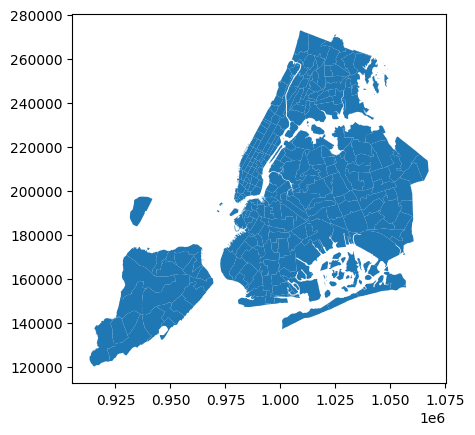

In [8]:
zones.plot()

In [9]:
# shapefile
zones = gpd.read_file("taxi_zones/taxi_zones.shp")

In [10]:
sbm_cluster_assignment_dict = np.load('sbm_runs_taxi/sbm_0/cluster_assignment_dict.npy', allow_pickle=True).item()

In [11]:
len(sbm_cluster_assignment_dict)

259

In [12]:
print(type(sbm_cluster_assignment_dict))
print(len(sbm_cluster_assignment_dict))
print(list(sbm_cluster_assignment_dict.items())[:10])

<class 'dict'>
259
[(234, 8), (186, 20), (164, 20), (50, 7), (162, 1), (229, 2), (114, 14), (143, 19), (161, 11), (142, 10)]


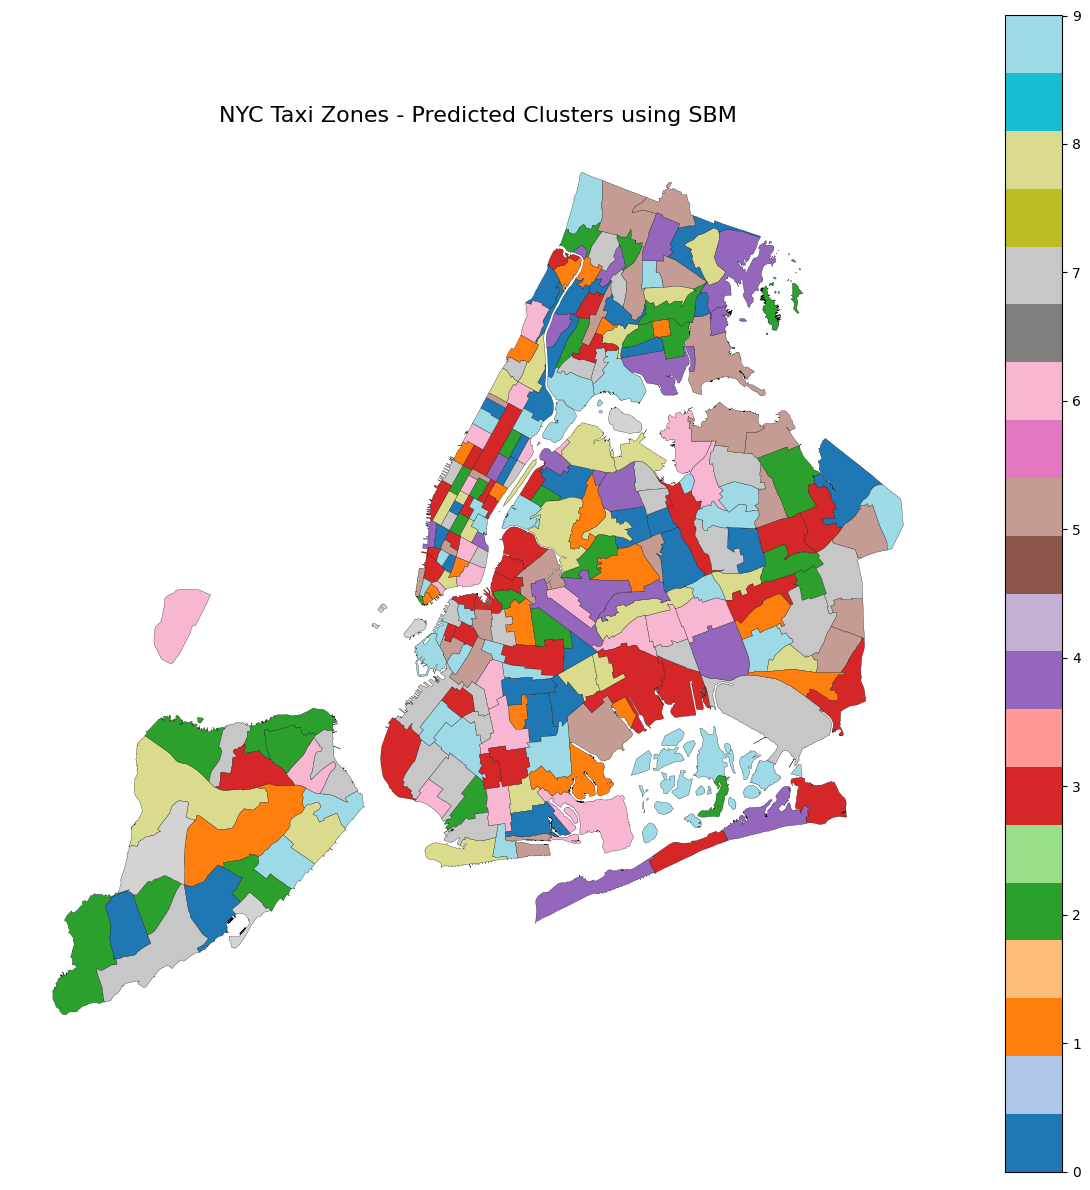

In [13]:
# 1.Read clusters
sbm_cluster_assignment_dict = np.load('sbm_runs_taxi/sbm_51/cluster_assignment_dict.npy', allow_pickle=True).item()

# 2. dict → dataframe
cluster_df_sbm = pd.DataFrame({
    "LocationID": list(sbm_cluster_assignment_dict.keys()),
    "predicted_cluster": list(sbm_cluster_assignment_dict.values())
})

cluster_df_sbm["LocationID"] = cluster_df_sbm["LocationID"].astype(int)

# 3. merge
map_df_sbm = zones.merge(cluster_df_sbm, on="LocationID", how="left")

# 4. plot
fig, ax = plt.subplots(figsize=(12, 12))

map_df_sbm.plot(
    column="predicted_cluster",
    cmap="tab20",
    legend=True,
    linewidth=0.2,
    edgecolor="black",
    missing_kwds={"color": "lightgrey", "label": "Not used"},
    ax=ax
)

ax.set_title("NYC Taxi Zones - Predicted Clusters using SBM", fontsize=16)
ax.axis("off")

plt.tight_layout()
plt.show()

In [14]:
print("Total zones in shapefile:", len(zones))
print("Clusters assigned:", len(cluster_df_sbm))
print("Missing zones:", map_df_sbm["predicted_cluster"].isna().sum())

Total zones in shapefile: 263
Clusters assigned: 259
Missing zones: 6


In [15]:
missing = map_df_sbm[map_df_sbm["predicted_cluster"].isna()]
print(missing[["LocationID", "zone", "borough"]])

     LocationID                                           zone        borough
98           99                                Freshkills Park  Staten Island
102         103  Governor's Island/Ellis Island/Liberty Island      Manhattan
103         104  Governor's Island/Ellis Island/Liberty Island      Manhattan
104         105  Governor's Island/Ellis Island/Liberty Island      Manhattan
109         110                               Great Kills Park  Staten Island
198         199                                  Rikers Island          Bronx


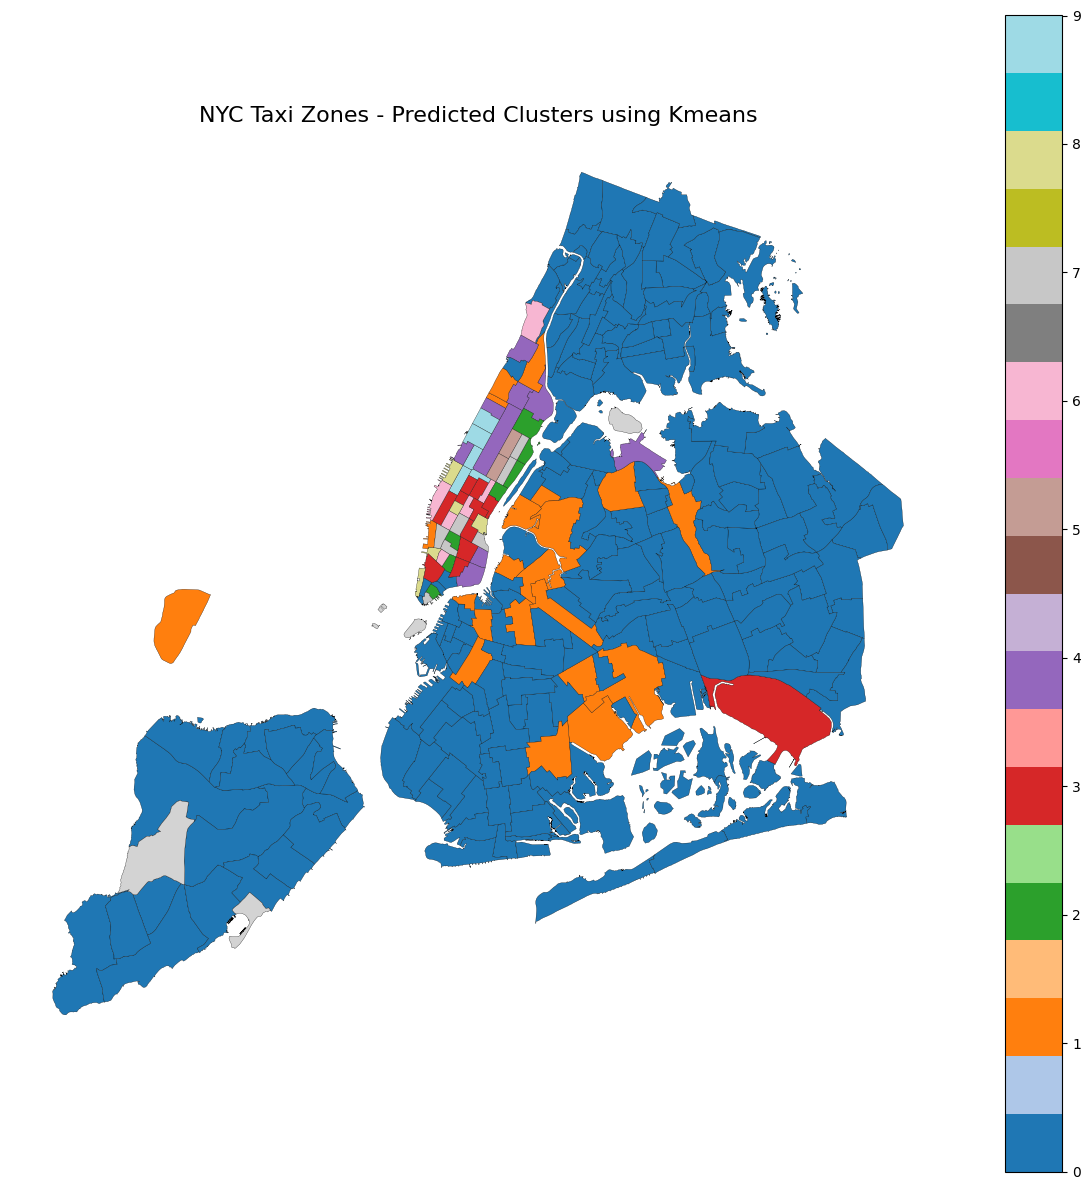

In [16]:
# 1.Read clusters
kmeans_cluster_assignment_dict = np.load('kmeans_runs_taxi/pca_cluster_assignment_dict_tuned_0.npy', allow_pickle=True).item()

# 2. dict → dataframe
cluster_df_kmeans = pd.DataFrame({
    "LocationID": list(kmeans_cluster_assignment_dict.keys()),
    "predicted_cluster": list(kmeans_cluster_assignment_dict.values())
})
cluster_df_kmeans["LocationID"] = cluster_df_kmeans["LocationID"].astype(int)
# 3. merge
map_df_kmeans = zones.merge(cluster_df_kmeans, on="LocationID", how="left")

# 4. plot
fig, ax = plt.subplots(figsize=(12, 12))

map_df_kmeans.plot(
    column="predicted_cluster",
    cmap="tab20",
    legend=True,
    linewidth=0.2,
    edgecolor="black",
    missing_kwds={"color": "lightgrey", "label": "Not used"},
    ax=ax
)

ax.set_title("NYC Taxi Zones - Predicted Clusters using Kmeans", fontsize=16)
ax.axis("off")

plt.tight_layout()
plt.show()

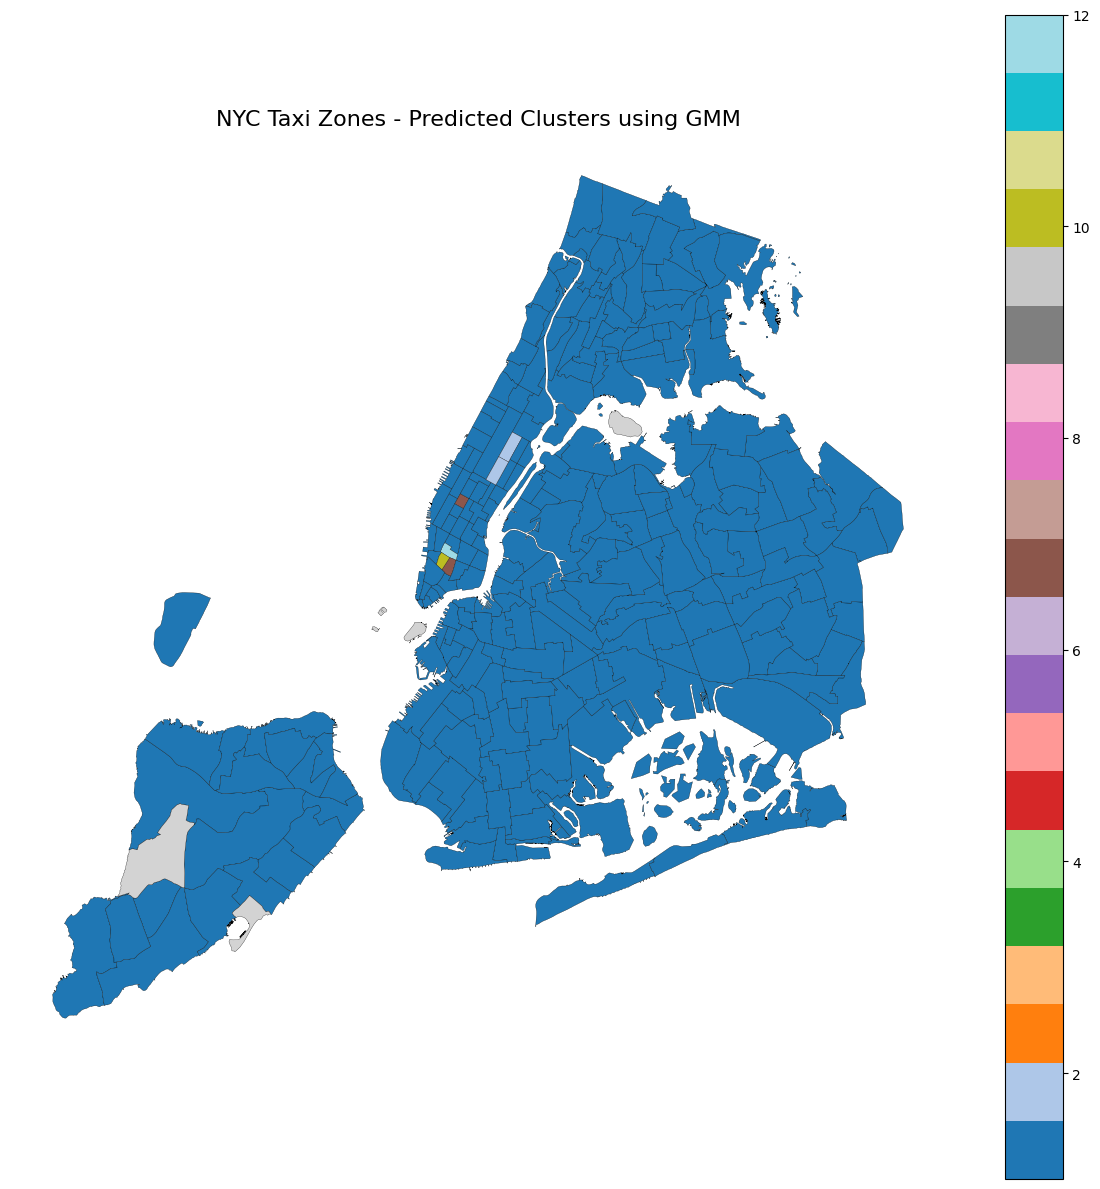

In [17]:
# 1.Read clusters
gmm_cluster_assignment_dict = np.load('gmm_runs_taxi/vmog_cluster_assignment_dict_tuned_5.npy', allow_pickle=True).item()

# 2. dict → dataframe
cluster_df_gmm = pd.DataFrame({
    "LocationID": list(gmm_cluster_assignment_dict.keys()),
    "predicted_cluster": list(gmm_cluster_assignment_dict.values())
})
cluster_df_gmm["LocationID"] = cluster_df_gmm["LocationID"].astype(int)
# 3. merge
map_df_gmm = zones.merge(cluster_df_gmm, on="LocationID", how="left")

# 4. plot
fig, ax = plt.subplots(figsize=(12, 12))

map_df_gmm.plot(
    column="predicted_cluster",
    cmap="tab20",
    legend=True,
    linewidth=0.2,
    edgecolor="black",
    missing_kwds={"color": "lightgrey", "label": "Not used"},
    ax=ax
)

ax.set_title("NYC Taxi Zones - Predicted Clusters using GMM", fontsize=16)
ax.axis("off")

plt.tight_layout()
plt.show()

In [18]:
for i in range(0, 10):
    gmm_cluster_assignment_dict = np.load(
        f'sbm_runs_taxi/sbm_51/cluster_assignment_dict.npy',
        allow_pickle=True
    ).item()
    
    clusters = list(gmm_cluster_assignment_dict.values())
    print(f"Run {i}: {len(np.unique(clusters))} clusters")

Run 0: 10 clusters
Run 1: 10 clusters
Run 2: 10 clusters
Run 3: 10 clusters
Run 4: 10 clusters
Run 5: 10 clusters
Run 6: 10 clusters
Run 7: 10 clusters
Run 8: 10 clusters
Run 9: 10 clusters


In [19]:
for i in range(0, 10):
    gmm_cluster_assignment_dict = np.load(
        f'gmm_runs_taxi/vmog_cluster_assignment_dict_tuned_{i}.npy',
        allow_pickle=True
    ).item()
    
    clusters = list(gmm_cluster_assignment_dict.values())
    print(f"Run {i}: {len(np.unique(clusters))} clusters")

Run 0: 6 clusters
Run 1: 5 clusters
Run 2: 6 clusters
Run 3: 6 clusters
Run 4: 3 clusters
Run 5: 5 clusters
Run 6: 3 clusters
Run 7: 5 clusters
Run 8: 6 clusters
Run 9: 4 clusters


In [20]:
true_labels = zones['borough']
true_labels

0                EWR
1             Queens
2              Bronx
3          Manhattan
4      Staten Island
           ...      
258            Bronx
259           Queens
260        Manhattan
261        Manhattan
262        Manhattan
Name: borough, Length: 263, dtype: object

In [21]:
pred_labels = list(kmeans_cluster_assignment_dict.values())

In [22]:
import numpy as np
from scipy.optimize import linear_sum_assignment

def confusion_matrix(X, Y):
    assert len(X) == len(Y)

    unique_x = np.unique(X)
    unique_y = np.unique(Y)

    x_dict = {unique_x[i]: i for i in range(len(unique_x))}
    y_dict = {unique_y[i]: i for i in range(len(unique_y))}

    cm = np.zeros((len(unique_x), len(unique_y)), dtype=int)

    for i in range(len(X)):
        cm[x_dict[X[i]], y_dict[Y[i]]] += 1

    return cm, unique_x, unique_y


def compare_two_assignments(assignment_A, assignment_B):
    cm, unique_x, unique_y = confusion_matrix(assignment_A, assignment_B)

    row_ind, col_ind = linear_sum_assignment(cm, maximize=True)
    score = cm[row_ind, col_ind].sum()

    aligned_cm = cm[:, col_ind]
    aligned_pred_labels = unique_y[col_ind]

    return score, aligned_cm, unique_x, aligned_pred_labels

In [23]:
eval_df = map_df_sbm.dropna(subset=['borough', 'predicted_cluster']).copy()

assignment_A = eval_df['borough'].values
assignment_B = eval_df['predicted_cluster'].values

score, aligned_cm, row_labels, col_labels = compare_two_assignments(assignment_A, assignment_B)

print("Hungarian score:", score)
print("Row labels:", row_labels)
print("Column labels after alignment:", col_labels)
print(aligned_cm)

Hungarian score: 43
Row labels: ['Bronx' 'Brooklyn' 'EWR' 'Manhattan' 'Queens' 'Staten Island']
Column labels after alignment: [5. 3. 6. 0. 4. 2.]
[[ 6  2  0  7  6  7]
 [ 6 13  7  5  1  3]
 [ 0  0  1  0  0  0]
 [ 4 10  8  9  4  5]
 [ 7 10  5  6  8  6]
 [ 0  1  1  2  0  6]]


In [24]:
eval_df = map_df_kmeans.dropna(subset=['borough', 'predicted_cluster']).copy()

assignment_A = eval_df['borough'].values
assignment_B = eval_df['predicted_cluster'].values

score, aligned_cm, row_labels, col_labels = compare_two_assignments(assignment_A, assignment_B)

print("Hungarian score:", score)
print("Row labels:", row_labels)
print("Column labels after alignment:", col_labels)
print(aligned_cm)

Hungarian score: 83
Row labels: ['Bronx' 'Brooklyn' 'EWR' 'Manhattan' 'Queens' 'Staten Island']
Column labels after alignment: [4. 1. 2. 3. 0. 5.]
[[ 0  0  0  0 42  0]
 [ 0 11  0  0 50  0]
 [ 0  1  0  0  0  0]
 [ 8  4  7 10 12  2]
 [ 1  5  0  1 62  0]
 [ 0  0  0  0 18  0]]


In [25]:
eval_df = map_df_gmm.dropna(subset=['borough', 'predicted_cluster']).copy()

assignment_A = eval_df['borough'].values
assignment_B = eval_df['predicted_cluster'].values

score, aligned_cm, row_labels, col_labels = compare_two_assignments(assignment_A, assignment_B)

print("Hungarian score:", score)
print("Row labels:", row_labels)
print("Column labels after alignment:", col_labels)
print(aligned_cm)

Hungarian score: 71
Row labels: ['Bronx' 'Brooklyn' 'EWR' 'Manhattan' 'Queens' 'Staten Island']
Column labels after alignment: [10.  7. 12.  2.  1.]
[[ 0  0  0  0 42]
 [ 0  0  0  0 61]
 [ 0  0  0  0  1]
 [ 1  2  1  2 60]
 [ 0  0  0  0 69]
 [ 0  0  0  0 18]]


In [26]:
ground_truth = map_df_gmm[['LocationID', 'borough']].copy()

In [27]:
def get_score_for_one_run(cluster_dict, ground_truth_df):
    cluster_df = pd.DataFrame({
        'LocationID': list(cluster_dict.keys()),
        'predicted_cluster': list(cluster_dict.values())
    })

    gt_df = ground_truth_df.copy()

    gt_df['LocationID'] = gt_df['LocationID'].astype(int)
    cluster_df['LocationID'] = cluster_df['LocationID'].astype(int)

    eval_df = gt_df.merge(cluster_df, on='LocationID', how='left')
    eval_df = eval_df.dropna(subset=['borough', 'predicted_cluster']).copy()

    assignment_A = eval_df['borough'].values
    assignment_B = eval_df['predicted_cluster'].values

    score, aligned_cm, row_labels, col_labels = compare_two_assignments(assignment_A, assignment_B)
    return score, aligned_cm

sbm

In [28]:
sbm_scores = []
sbm_cms = []

for i in range(48):
    cluster_dict = np.load(
        f'sbm_runs_taxi/sbm_{i}/cluster_assignment_dict.npy',
        allow_pickle=True
    ).item()

    score, aligned_cm = get_score_for_one_run(cluster_dict, ground_truth)
    sbm_scores.append(score)
    sbm_cms.append(aligned_cm)

sbm_scores = np.array(sbm_scores)
sbm_scores

array([34, 34, 30, 38, 32, 30, 34, 31, 33, 31, 30, 31, 36, 32, 32, 33, 34,
       38, 29, 37, 43, 28, 40, 36, 33, 31, 42, 30, 26, 32, 35, 32, 32, 36,
       30, 46, 30, 40, 31, 38, 28, 31, 33, 42, 30, 32, 32, 31])

In [37]:
sbm_scores = []
sbm_cms = []

for i in range(48):
    cluster_dict = np.load(
        f'credible_interval_results/sbm_{i}/cluster_assignment_dict.npy',
        allow_pickle=True
    ).item()

    score, aligned_cm = get_score_for_one_run(cluster_dict, ground_truth)
    sbm_scores.append(score)
    sbm_cms.append(aligned_cm)

sbm_scores = np.array(sbm_scores)
sbm_scores

array([38, 36, 32, 38, 33, 33, 31, 32, 36, 35, 37, 32, 35, 32, 39, 36, 38,
       35, 37, 34, 32, 35, 37, 34, 34, 33, 32, 32, 34, 39, 34, 32, 37, 33,
       38, 32, 34, 30, 38, 32, 32, 38, 31, 38, 31, 36, 32, 32])

kmeans

In [30]:
kmeans_scores = []
kmeans_cms = []

for i in range(48):
    cluster_dict = np.load(
        f'kmeans_runs_taxi/pca_cluster_assignment_dict_tuned_{i}.npy',
        allow_pickle=True
    ).item()

    score, aligned_cm = get_score_for_one_run(cluster_dict, ground_truth)
    kmeans_scores.append(score)
    kmeans_cms.append(aligned_cm)

kmeans_scores = np.array(kmeans_scores)

gmm

In [31]:
gmm_scores = []
gmm_cms = []

for i in range(48):
    cluster_dict = np.load(
        f'gmm_runs_taxi/vmog_cluster_assignment_dict_tuned_{i}.npy',
        allow_pickle=True
    ).item()

    score, aligned_cm = get_score_for_one_run(cluster_dict, ground_truth)
    gmm_scores.append(score)
    gmm_cms.append(aligned_cm)

gmm_scores = np.array(gmm_scores)

In [32]:
def summarize_scores(scores):
    mean = np.mean(scores)
    lower = np.percentile(scores, 2.5)
    upper = np.percentile(scores, 97.5)
    return mean, lower, upper

In [33]:
print("SBM:", summarize_scores(sbm_scores))
print("KMeans:", summarize_scores(kmeans_scores))
print("GMM:", summarize_scores(gmm_scores))

SBM: (np.float64(32.0), np.float64(32.0), np.float64(32.0))
KMeans: (np.float64(80.60416666666667), np.float64(72.175), np.float64(89.64999999999999))
GMM: (np.float64(70.8125), np.float64(69.0), np.float64(72.0))


C:\Users\ROG\AppData\Local\Temp\ipykernel_2520\3522306321.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(score_lists, labels=methods, patch_artist=True)


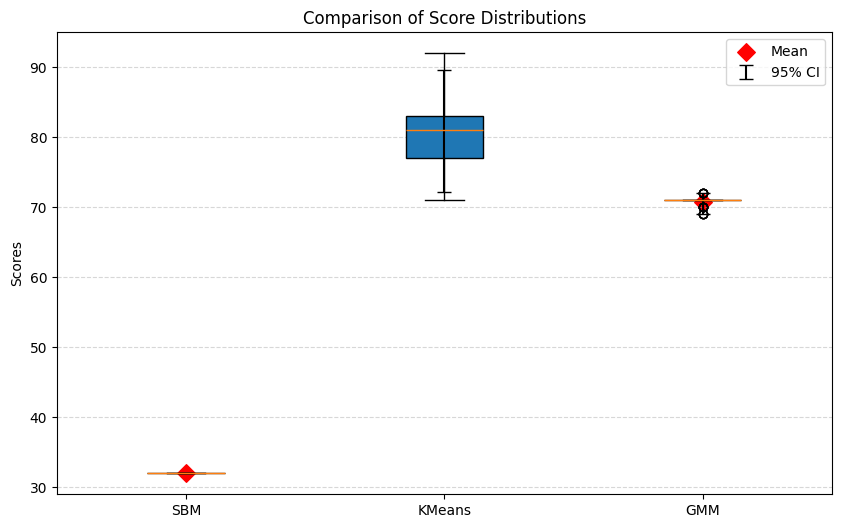

In [34]:
import matplotlib.pyplot as plt

methods = ['SBM', 'KMeans', 'GMM']
score_lists = [sbm_scores, kmeans_scores, gmm_scores]

means = [np.mean(s) for s in score_lists]
lowers = [np.percentile(s, 2.5) for s in score_lists]
uppers = [np.percentile(s, 97.5) for s in score_lists]

x = np.arange(len(methods))

plt.figure(figsize=(10, 6))

plt.boxplot(score_lists, labels=methods, patch_artist=True)

plt.scatter(x + 1, means, color='red', marker='D', s=80, label='Mean')

yerr = [
    np.array(means) - np.array(lowers),
    np.array(uppers) - np.array(means)
]
plt.errorbar(
    x + 1,
    means,
    yerr=yerr,
    fmt='none',
    ecolor='black',
    capsize=5,
    label='95% CI'
)

plt.ylabel("Scores")
plt.title("Comparison of Score Distributions")
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()